<a href="https://colab.research.google.com/github/MayerT1/LiDAR_Dev/blob/main/sewanee_2d_cnn_patch_based_multisensor_fusion_gedi_rs_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install gdal
!pip install laspy
!pip install lazrs
!pip install rasterio
!pip install retry

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.3/84.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 639.6/639.6 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 kB 2.5 MB/s eta 0:00:00


In [ ]:
# Install necessary packages
!pip install geemap geopandas scikit-learn tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 17.2 MB/s eta 0:00:00


In [ ]:
# Authenticate and initialize Earth Engine
import ee
import geemap
import geemap.chart as chart
ee.Authenticate()
ee.Initialize(project='servir-sco-assets')
Map = geemap.Map()



from google.colab import drive
drive.mount('/content/drive/')


Mounted at /content/drive/


In [ ]:
import ee
import geemap
import geopandas as gpd
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
import tensorflow as tf
from tensorflow.keras import layers, models
import folium


In [ ]:
%cd /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_32

/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_32


In [ ]:
# !mkdir test
# !mkdir train
# !mkdir val

In [ ]:
# !mkdir y_pai
# !mkdir y_pai/y_test
# !mkdir y_pai/y_train
# !mkdir y_pai/y_val

In [ ]:
# !mkdir y_fhd
# !mkdir y_fhd/y_test
# !mkdir y_fhd/y_train
# !mkdir y_fhd/y_val

In [ ]:
# !mkdir y_ch
# !mkdir y_ch/y_test
# !mkdir y_ch/y_train
# !mkdir y_ch/y_val

In [ ]:
s1Ascending_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/s1Ascending_2021")
DEMindices_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/s1Ascending_2021")
GEDIindicesA_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/GEDIindicesA_2021")
GEDIindicesB_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/GEDIindicesB_2021")
HLS_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/HLS_2021")
LandsatComposite_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/LandsatComposite_2021")
LandsatIndices_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/LandsatIndices_2021")
S2Composite_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/S2Composite_2021")
S2Indices_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/S2Indices_2021")
landsatTasseledCapIndices_2021 = ee.Image("projects/servir-sco-assets/assets/Rx_Fire/EO_Outputs/Sewanee/landsatTasseledCapIndices_2021")
ROI = ee.FeatureCollection('projects/servir-sco-assets/assets/Rx_Fire/Vector_Data/Sewanee_Domain')

# Map.addLayer(ROI, {}, 'ROI')
# Map.addLayer(s1Ascending_2021, {}, 's1Ascending_2021')
# Map.addLayer(DEMindices_2021, {}, 'DEMindices_2021')
# Map.addLayer(GEDIindicesA_2021, {}, 'GEDIindicesA_2021')
# Map.addLayer(GEDIindicesB_2021, {}, 'GEDIindicesB_2021')
# Map.addLayer(HLS_2021, {}, 'HLS_2021')
# Map.addLayer(LandsatComposite_2021, {}, 'LandsatComposite_2021')
# Map.addLayer(LandsatIndices_2021, {}, 'LandsatIndices_2021')
# Map.addLayer(S2Composite_2021, {}, 'S2Composite_2021')
# Map.addLayer(S2Indices_2021, {}, 'S2Indices_2021')
# Map.addLayer(landsatTasseledCapIndices_2021, {}, 'landsatTasseledCapIndices_2021')


# stacked = s1Ascending_2022.addBands(s1Descending_2022).addBands(DEMindices_2022).addBands(LandsatComposite_2022).addBands(LandsatIndices_2022).addBands(landsatTasseledCapIndices_2022).addBands(HLS_2022).addBands(S2Composite_2022).addBands(S2Indices_2022)
stacked = s1Ascending_2021.addBands(DEMindices_2021).addBands(LandsatComposite_2021).addBands(LandsatIndices_2021).addBands(landsatTasseledCapIndices_2021).addBands(HLS_2021).addBands(S2Composite_2021).addBands(S2Indices_2021)

Map.addLayer(stacked, {}, 'stacked');

#//////////////////////////////////////////////////////////////////////////////////
glad = ee.Image("projects/glad/GLCLU2020/Forest_height_2020").clip(ROI)
Map.addLayer(glad, {}, "glad")
glad = glad.gte(1).select(['b1']).rename(['class']);
#print("glad", glad)

classMask = GEDIindicesA_2021.addBands(glad)
Map.addLayer(classMask, {}, "classMask")
#print("classMask", classMask)

proj = GEDIindicesA_2021.projection()
grid = ROI.geometry().coveringGrid(proj, 30)
grid = ee.FeatureCollection(grid).randomColumn("random", 42);
#print("spatial_partition number of boxes in the grid", grid.size())
val_samp = grid.filter('random <= 0.1').set("samp_type","val_samp");
test_samp = grid.filter('random <= 0.3 and random >= 0.1').set("samp_type","test_samp");
train_samp = grid.filter('random >= 0.3').set("samp_type","train_samp");

#rint('val_samp 10%', val_samp.size());
Map.addLayer(val_samp, {"color": "blue"}, "val_samp 10%")

#print('test_samp 20%', test_samp.size());
Map.addLayer(test_samp, {"color": "red"}, "test_samp 20%")

#print('train_samp 70%', train_samp.size());
Map.addLayer(train_samp, {"color": "green"}, "train_samp 70%")

Map

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(childr…

In [ ]:
# ================================================================
# BLOCK 1 – create chips
# ================================================================
import ee, os, requests, shutil, multiprocessing, random
from retry import retry

# ee.Initialize(opt_url="https://earthengine-highvolume.googleapis.com")

# ------------ parameters you may change -------------------------
PIXELS      = 32         # chip width / height
SCALE       = 10           # metres per pixel
PERCENTAGE  = .1           # % of features to keep
N_WORKERS   = 12           # parallel download processes
BASE_DIR    = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_32"
# ----------------------------------------------------------------
DIMENSIONS  = f"{PIXELS}x{PIXELS}"
HALF_BUFFER = PIXELS * SCALE / 2

# # ------------ your stacked image --------------------------------
# stacked = (
#     s1Ascending_2021
#       .addBands(DEMindices_2021)
#       .addBands(LandsatComposite_2021)
#       .addBands(LandsatIndices_2021)
#       .addBands(landsatTasseledCapIndices_2021)
#       .addBands(HLS_2021)
#       .addBands(S2Composite_2021)
#       .addBands(S2Indices_2021)
# )

# ------------ helpers -------------------------------------------
def get_geoms(fc):
    """Return client-side list of GeoJSON geometries."""
    return fc.aggregate_array(".geo").getInfo()

@retry(tries=10, delay=1, backoff=2)
def download_chip(idx, geom, out_dir, prefix="chip_"):
    """Download one NPY chip centred on *geom*."""
    region = ee.Geometry(geom).centroid(maxError=1).buffer(HALF_BUFFER).bounds()
    url    = stacked.getDownloadURL({"region": region,
                                     "dimensions": DIMENSIONS,
                                     "format": "NPY"})
    r = requests.get(url, stream=True)
    r.raise_for_status()
    fn = os.path.join(out_dir, f"{prefix}{str(idx).zfill(6)}.npy")
    with open(fn, "wb") as fp:
        shutil.copyfileobj(r.raw, fp)

def process_set(fc, name):
    # -------- sample PERCENTAGE % reproducibly
    sampled = (fc.randomColumn("rnd", seed=42)
                 .filter(f"rnd < {PERCENTAGE/100.0}"))
    n = sampled.size().getInfo()
    print(f"\n{name.upper()} → {n} chips will be created "
          f"({PERCENTAGE}% of original).")
    if input("Type 'y' + <Enter> to proceed: ").lower() != "y":
        print("Skipped.")
        return

    out_dir = os.path.join(BASE_DIR, name)
    os.makedirs(out_dir, exist_ok=True)

    geoms = get_geoms(sampled)
    pool  = multiprocessing.Pool(N_WORKERS)
    pool.starmap(download_chip,
                 [(i, g, out_dir) for i, g in enumerate(geoms)])
    pool.close(); pool.join()
    print(f"✓  {n} chips written → {out_dir}")

# ------------ run all three sets --------------------------------
SETS = {"train": train_samp, "test": test_samp, "val": val_samp}
for set_name, fc in SETS.items():
    process_set(fc, set_name)


TRAIN → 56 chips will be created (0.1% of original).
Type 'y' + <Enter> to proceed: y


✓  56 chips written → /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_32/train

TEST → 14 chips will be created (0.1% of original).
Type 'y' + <Enter> to proceed: y


✓  14 chips written → /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_32/test

VAL → 11 chips will be created (0.1% of original).
Type 'y' + <Enter> to proceed: y


✓  11 chips written → /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_32/val


Chip shape: (32, 32, 48)
Band names: ('VV', 'VH', 'ratio', 'ndratio', 'VV_1', 'VH_1', 'ratio_1', 'ndratio_1', 'red', 'green', 'blue', 'nir', 'swir1', 'swir2', 'NDVI', 'NDWI', 'MNDWI', 'SAVI', 'NDMI', 'NDBI', 'NBR', 'brightness', 'greenness', 'wetness', 'fourth', 'fifth', 'sixth', 'NDVI_1', 'NDWI_1', 'MNDWI_1', 'SAVI_1', 'NDMI_1', 'NDBI_1', 'NBR_1', 'red_1', 'green_1', 'blue_1', 'nir_1', 'swir1_1', 'swir2_1', 'S2_NDVI', 'S2_NDWI', 'S2_EVI', 'S2_MNDWI', 'S2_SAVI', 'S2_NDMI', 'S2_NDBI', 'S2_NBR')


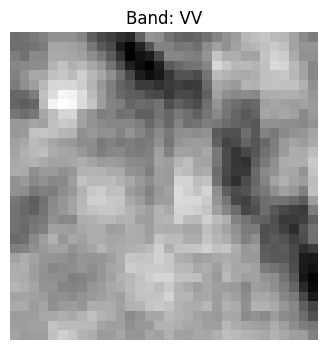

Map(center=[35.235012055380786, -85.97693593259385], controls=(WidgetControl(options=['position', 'transparent…

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import geemap, ee
# ee.Initialize(opt_url="https://earthengine-highvolume.googleapis.com")

# ---------- Load the .npy chip ----------
npy_path = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_32/train/chip_000001.npy"
chip_struct = np.load(npy_path)

# Convert structured array to regular 3D NumPy array
band_names = chip_struct.dtype.names
chip_array = np.stack([chip_struct[name] for name in band_names], axis=-1)

print("Chip shape:", chip_array.shape)
print("Band names:", band_names)

# ---------- Visualize first band ----------
plt.figure(figsize=(4, 4))
plt.imshow(chip_array[:, :, 0], cmap="gray")
plt.title(f"Band: {band_names[0]}")
plt.axis("off")
plt.show()

# ---------- Display on a Map ----------
PIXELS = 32
SCALE = 10
HALF_BUFFER = PIXELS * SCALE / 2
PERCENTAGE = 10
IDX = 1  # chip_000001 index

sampled_train = (
    train_samp.randomColumn("rnd", seed=42)
              .filter(f"rnd < {PERCENTAGE / 100.0}")
)

geom_list = sampled_train.aggregate_array(".geo").getInfo()
chip_geom = ee.Geometry(geom_list[IDX])
chip_reg = chip_geom.centroid(maxError=1).buffer(HALF_BUFFER).bounds()

m = geemap.Map()
m.addLayer(chip_reg, {"color": "red"}, "chip_000001 footprint")
m.centerObject(chip_reg, 11)
display(m)

In [ ]:
y_stacked_fhd = GEDIindicesB_2021.select("fhd_normal")#GEDIindicesA_2022.select('rh98')#GEDIindicesB_2022.select("fhd_normal")#GEDIindicesA_2022.select('rh.*')#.addBands(GEDIindicesB_2022.select('rh.*'))
# print(y_stacked_fhd.bandNames())
Map.addLayer(y_stacked_fhd, {}, 'y_stacked_fhd')

y_stacked_ch = GEDIindicesA_2021.select('rh98')#GEDIindicesB_2022.select("fhd_normal")#GEDIindicesA_2022.select('rh.*')#.addBands(GEDIindicesB_2022.select('rh.*'))
# print(y_stacked_ch.bandNames())
Map.addLayer(y_stacked_ch, {}, 'y_stacked_ch')

y_stacked_pai = GEDIindicesB_2021.select("pai")#GEDIindicesA_2022.select('rh98')#GEDIindicesB_2022.select("fhd_normal")#GEDIindicesA_2022.select('rh.*')#.addBands(GEDIindicesB_2022.select('rh.*'))
# print(y_stacked_pai.bandNames())
Map.addLayer(y_stacked_pai, {}, 'y_stacked_pai')


Map


Map(bottom=812.0, center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=Search…

In [ ]:
# !mkdir y_pai
# !mkdir y_pai/y_test
# !mkdir y_pai/y_train
# !mkdir y_pai/y_val

# !mkdir y_fhd
# !mkdir y_fhd/y_test
# !mkdir y_fhd/y_train
# !mkdir y_fhd/y_val

# !mkdir y_ch
# !mkdir y_ch/y_test
# !mkdir y_ch/y_train
# !mkdir y_ch/y_val

mkdir: cannot create directory ‘y_pai’: File exists
mkdir: cannot create directory ‘y_pai/y_test’: File exists
mkdir: cannot create directory ‘y_pai/y_train’: File exists
mkdir: cannot create directory ‘y_pai/y_val’: File exists
mkdir: cannot create directory ‘y_fhd’: File exists
mkdir: cannot create directory ‘y_fhd/y_test’: File exists
mkdir: cannot create directory ‘y_fhd/y_train’: File exists
mkdir: cannot create directory ‘y_fhd/y_val’: File exists


In [ ]:
# ================================================================
# BLOCK – create target chips for y_fhd, y_ch, y_pai
# ================================================================
import ee, os, requests, shutil, multiprocessing
from retry import retry

# ------------ parameters you may change -------------------------
PIXELS      = 32         # chip width / height
SCALE       = 10           # metres per pixel
PERCENTAGE  = 0.1          # % of features to keep
N_WORKERS   = 12           # parallel download processes
BASE_DIR    = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_32"
# ----------------------------------------------------------------
DIMENSIONS  = f"{PIXELS}x{PIXELS}"
HALF_BUFFER = PIXELS * SCALE / 2

# ------------ target stacks dictionary --------------------------
target_stacks = {
    "y_fhd": y_stacked_fhd,
    "y_ch": y_stacked_ch,
    "y_pai": y_stacked_pai
}

# ------------ helpers -------------------------------------------
def get_geoms(fc):
    """Return client-side list of GeoJSON geometries."""
    return fc.aggregate_array(".geo").getInfo()

@retry(tries=10, delay=1, backoff=2)
def download_chip(idx, geom, out_dir, stack, prefix="chip_"):
    """Download one NPY chip centred on *geom*."""
    region = ee.Geometry(geom).centroid(maxError=1).buffer(HALF_BUFFER).bounds()
    url    = stack.getDownloadURL({
        "region": region,
        "dimensions": DIMENSIONS,
        "format": "NPY"
    })
    r = requests.get(url, stream=True)
    r.raise_for_status()
    fn = os.path.join(out_dir, f"{prefix}{str(idx).zfill(6)}.npy")
    with open(fn, "wb") as fp:
        shutil.copyfileobj(r.raw, fp)

def process_set(fc, name, stack, subfolder):
    """Sample, prompt, download chips for a given set and target stack."""
    # Sample PERCENTAGE % reproducibly
    sampled = (fc.randomColumn("rnd", seed=42)
                 .filter(f"rnd < {PERCENTAGE / 100.0}"))
    n = sampled.size().getInfo()
    print(f"\n{(subfolder + ' / ' + name).upper()} → {n} chips will be created "
          f"({PERCENTAGE}% of original).")
    if input("Type 'y' + <Enter> to proceed: ").lower() != "y":
        print("Skipped.")
        return

    out_dir = os.path.join(BASE_DIR, subfolder, name)
    os.makedirs(out_dir, exist_ok=True)

    geoms = get_geoms(sampled)
    pool = multiprocessing.Pool(N_WORKERS)
    pool.starmap(download_chip, [(i, g, out_dir, stack) for i, g in enumerate(geoms)])
    pool.close(); pool.join()
    print(f"✓  {n} chips written → {out_dir}")

# ------------ run all targets for all sets -----------------------
SETS = {"y_train": train_samp, "y_test": test_samp, "y_val": val_samp}

for subfolder, stack in target_stacks.items():
    for set_name, fc in SETS.items():
        process_set(fc, set_name, stack, subfolder)



Y_FHD / Y_TRAIN → 56 chips will be created (0.1% of original).
Type 'y' + <Enter> to proceed: y


✓  56 chips written → /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_32/y_fhd/y_train

Y_FHD / Y_TEST → 14 chips will be created (0.1% of original).
Type 'y' + <Enter> to proceed: y


✓  14 chips written → /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_32/y_fhd/y_test

Y_FHD / Y_VAL → 11 chips will be created (0.1% of original).
Type 'y' + <Enter> to proceed: y


✓  11 chips written → /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_32/y_fhd/y_val

Y_CH / Y_TRAIN → 56 chips will be created (0.1% of original).
Type 'y' + <Enter> to proceed: y


✓  56 chips written → /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_32/y_ch/y_train

Y_CH / Y_TEST → 14 chips will be created (0.1% of original).
Type 'y' + <Enter> to proceed: y


✓  14 chips written → /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_32/y_ch/y_test

Y_CH / Y_VAL → 11 chips will be created (0.1% of original).
Type 'y' + <Enter> to proceed: y


✓  11 chips written → /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_32/y_ch/y_val

Y_PAI / Y_TRAIN → 56 chips will be created (0.1% of original).
Type 'y' + <Enter> to proceed: y


✓  56 chips written → /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_32/y_pai/y_train

Y_PAI / Y_TEST → 14 chips will be created (0.1% of original).
Type 'y' + <Enter> to proceed: y


✓  14 chips written → /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_32/y_pai/y_test

Y_PAI / Y_VAL → 11 chips will be created (0.1% of original).
Type 'y' + <Enter> to proceed: y


✓  11 chips written → /content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_32/y_pai/y_val


Chip shape: (32, 32, 1)
Band names: ('fhd_normal',)


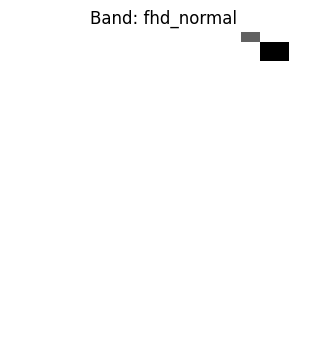

Map(center=[35.235012820623496, -85.97692755445384], controls=(WidgetControl(options=['position', 'transparent…

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import geemap, ee
# ee.Initialize(opt_url="https://earthengine-highvolume.googleapis.com")

# ---------- Load the .npy chip ----------
npy_path = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_32/y_fhd/y_train/chip_000001.npy"
chip_struct = np.load(npy_path)

# Convert structured array to regular 3D NumPy array
band_names = chip_struct.dtype.names
chip_array = np.stack([chip_struct[name] for name in band_names], axis=-1)

print("Chip shape:", chip_array.shape)
print("Band names:", band_names)

# ---------- Visualize first band ----------
plt.figure(figsize=(4, 4))
plt.imshow(chip_array[:, :, 0], cmap="gray")
plt.title(f"Band: {band_names[0]}")
plt.axis("off")
plt.show()

# ---------- Display on a Map ----------
PIXELS = 128
SCALE = 10
HALF_BUFFER = PIXELS * SCALE / 2
PERCENTAGE = 10
IDX = 1  # chip_000001 index

sampled_train = (
    train_samp.randomColumn("rnd", seed=42)
              .filter(f"rnd < {PERCENTAGE / 100.0}")
)

geom_list = sampled_train.aggregate_array(".geo").getInfo()
chip_geom = ee.Geometry(geom_list[IDX])
chip_reg = chip_geom.centroid(maxError=1).buffer(HALF_BUFFER).bounds()

m = geemap.Map()
m.addLayer(chip_reg, {"color": "red"}, "chip_000001 footprint")
m.centerObject(chip_reg, 11)
display(m)

Data loading

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

PATCH_SIZE = 32
DATA_DIR = "/content/drive/MyDrive/PhD_Main_Folder/Geo_Data/Sewanee_32"
TARGETS = ['ch', 'fhd', 'pai']
BATCH_SIZE = 32
EPOCHS = 50


In [ ]:
from tqdm import tqdm

def load_data(x_dir, y_dir):
    X_list, Y_list = [], []

    for fname in tqdm(sorted(os.listdir(x_dir))):
        if fname.endswith('.npy'):
            x_path = os.path.join(x_dir, fname)
            y_path = os.path.join(y_dir, fname)

            x_chip = np.load(x_path)
            y_chip = np.load(y_path)

            if x_chip.dtype.names is not None:
                x_chip = np.stack([x_chip[field] for field in x_chip.dtype.names], axis=-1)
            x_chip = x_chip.astype(np.float32) / 10000.0  # Normalize input

            y_chip = y_chip.astype(np.float32)
            y_scalar = np.mean(y_chip)

            if np.isnan(x_chip).any() or np.isnan(y_scalar) or np.isinf(x_chip).any() or np.isinf(y_scalar):
                print(f"⚠️ Skipping due to NaNs or infs: {fname}")
                continue

            X_list.append(x_chip)
            Y_list.append(y_scalar)

    return np.array(X_list), np.array(Y_list)


In [ ]:
print("X_train shape:", X_train.shape)  # should be (N, 32, 32, num_bands)
print("y_train shape:", y_train.shape)  # should be (N, 32, 32)


X_train shape: (56, 32, 32, 48)
y_train shape: (56,)


In [ ]:
from tensorflow.keras import layers, models

def build_model(input_shape):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.GlobalAveragePooling2D(),
        layers.Dense(64, activation='relu'),
        layers.Dense(1)  # Regression
    ])
    return model


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

for target in TARGETS:
    print(f"\n\n🔁 Training for target: {target.upper()}")

    x_train_dir = os.path.join(DATA_DIR, 'train')
    y_train_dir = os.path.join(DATA_DIR, f'y_{target}', 'y_train')

    x_test_dir = os.path.join(DATA_DIR, 'test')
    y_test_dir = os.path.join(DATA_DIR, f'y_{target}', 'y_test')

    # Load data
    X_train, y_train = load_data(x_train_dir, y_train_dir)
    X_test, y_test = load_data(x_test_dir, y_test_dir)

    print(f"✅ Loaded {X_train.shape[0]} training samples for {target.upper()}")
    print(f"✅ Loaded {X_test.shape[0]} testing samples for {target.upper()}")

    # Build & compile model
    input_shape = (PATCH_SIZE, PATCH_SIZE, X_train.shape[-1])
    model = build_model(input_shape)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])

    # Train
    history = model.fit(X_train, y_train,
                        validation_data=(X_test, y_test),
                        epochs=EPOCHS,
                        batch_size=BATCH_SIZE,
                        verbose=2)

    # Plot loss + MAE
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{target.upper()} - MSE Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['mae'], label='Train MAE')
    plt.plot(history.history['val_mae'], label='Val MAE')
    plt.title(f'{target.upper()} - MAE')
    plt.xlabel('Epoch')
    plt.ylabel('MAE')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Predictions + Evaluation
    y_pred = model.predict(X_test).flatten()

    if np.isnan(y_pred).any():
        print("⚠️ Prediction contains NaNs. Skipping metrics.")
        continue

    print(f"\n📊 {target.upper()} Test Metrics:")
    print(f"MAE:  {mean_absolute_error(y_test, y_pred):.4f}")
    print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")
    print(f"R2:   {r2_score(y_test, y_pred):.4f}")

    # Save model
    model.save(f"{target}_regression_model.h5")




🔁 Training for target: CH


 11%|█         | 6/56 [00:00<00:00, 52.87it/s]

⚠️ Skipping due to NaNs or infs: chip_000000.npy
⚠️ Skipping due to NaNs or infs: chip_000001.npy
⚠️ Skipping due to NaNs or infs: chip_000002.npy
⚠️ Skipping due to NaNs or infs: chip_000003.npy
⚠️ Skipping due to NaNs or infs: chip_000004.npy
⚠️ Skipping due to NaNs or infs: chip_000005.npy
⚠️ Skipping due to NaNs or infs: chip_000006.npy
⚠️ Skipping due to NaNs or infs: chip_000007.npy
⚠️ Skipping due to NaNs or infs: chip_000008.npy


 21%|██▏       | 12/56 [00:00<00:00, 56.35it/s]

⚠️ Skipping due to NaNs or infs: chip_000009.npy
⚠️ Skipping due to NaNs or infs: chip_000010.npy
⚠️ Skipping due to NaNs or infs: chip_000011.npy


...

⚠️ Skipping due to NaNs or infs: chip_000009.npy


100%|██████████| 14/14 [00:00<00:00, 41.60it/s]

⚠️ Skipping due to NaNs or infs: chip_000010.npy
⚠️ Skipping due to NaNs or infs: chip_000011.npy
⚠️ Skipping due to NaNs or infs: chip_000012.npy
⚠️ Skipping due to NaNs or infs: chip_000013.npy
✅ Loaded 0 training samples for CH
✅ Loaded 0 testing samples for CH


Epoch 1/50


ValueError: Exception encountered when calling Sequential.call().

[1mInvalid input shape for input Tensor("data:0", shape=(32,), dtype=float32). Expected shape (None, 32, 32, 0), but input has incompatible shape (32,)[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=(32,), dtype=float32)
  • training=True
  • mask=None